# 1. Import Library dan Dataset

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/brain_tumor_dataset.csv')

#### Memberikan Styling Ke table agar lebih menarik

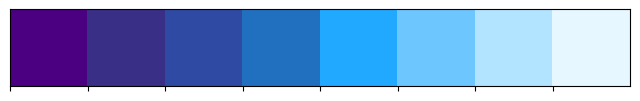

In [65]:
color = ["#4B0082", "#3a2f87", "#2e4aa3", "#2170c0", "#21A9FF", "#6DC6FE", "#B3E4FF", "#E6F7FF"]
df_style = {
    "border" : "1px solid black",
    "border-collapse" : "collapse",
    "font-size" : "14px",
    "color" : "white",
    "background-color" : color[-4]
}

table_style = [
    {"selector": "th", "props": [("background-color", color[0]), ("border", "1px solid black"), ("color", "white")]},
    {"selector": "th.col_heading", "props": [("background-color", color[0]), ("border", "1px solid black"), ("color", "white")]},
    {"selector": "th.row_headinf", "props": [("background-color", color[0]), ("border", "1px solid black"), ("color", "white")]},
    {"selector": "tr:nth-child(even) td", "props": [("background-color", color[2])]},
    {"selector": "tr:nth-child(odd) td", "props": [("background-color", color[1])]},
    {"selector": "td", "props": [("border", "1px solid black")]},
]


sns.palplot(sns.color_palette(color))

In [66]:
def target_column(s, target='Tumor_Type', prev_col='Gender'):
    styles = []
    for col in s.index:
        if col == target:
            styles.append(
            f'background-color: {color[2]} !important; ' 
            f'border-right: 1px solid gray !important; '
            f'border-left: 1px solid gray !important; '
            f'border-top: 1px solid {color[2]} !important; '
            f'border-bottom: 1px solid {color[2]} !important; '
            )
        elif col == prev_col:
            styles.append(f'border-right: 1px solid gray !important')
        else:
            styles.append('')
    return styles

def target_header(val, target='Tumor_Type', prev_col='Gender'):
    if val == target:
        return f'background-color: {color[2]} !important; border-right: 1px slid gray !important; border-left: 1px solid gray !important; color: white;'
    elif val == prev_col:
        return f'border-right: 1px solid gray !important'
    return ''

# 2. Exploratory Data Analyst

#### Identifikasi Data

In [67]:
df.head().style.set_properties(**df_style).set_table_styles(table_style).apply(target_column, axis=1).applymap_index(target_header, axis=1)

C:\Users\Admin\AppData\Local\Temp\ipykernel_14236\940045255.py:1: FutureWarning: Styler.applymap_index has been deprecated. Use Styler.map_index instead.
  df.head().style.set_properties(**df_style).set_table_styles(table_style).apply(target_column, axis=1).applymap_index(target_header, axis=1)


,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


nah gini kan lebih menarik

In [68]:
df = df.drop(columns=['Patient_ID'])
# Drop column ini karena hanya menampilkan id dari pasien(tidak informatif)

#### Analisa Data

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  20000 non-null  int64  
 1   Gender               20000 non-null  object 
 2   Tumor_Type           20000 non-null  object 
 3   Tumor_Size           20000 non-null  float64
 4   Location             20000 non-null  object 
 5   Histology            20000 non-null  object 
 6   Stage                20000 non-null  object 
 7   Symptom_1            20000 non-null  object 
 8   Symptom_2            20000 non-null  object 
 9   Symptom_3            20000 non-null  object 
 10  Radiation_Treatment  20000 non-null  object 
 11  Surgery_Performed    20000 non-null  object 
 12  Chemotherapy         20000 non-null  object 
 13  Survival_Rate        20000 non-null  float64
 14  Tumor_Growth_Rate    20000 non-null  float64
 15  Family_History       20000 non-null 

#### cek duplikasi data

In [70]:
df.duplicated().sum()

np.int64(0)

tidak ada kolom yang terduplikat

#### cek kolom yang nan/null

In [71]:
df.isna().sum().to_frame().T.style.set_properties(**df_style).set_table_styles(table_style)

,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


bagus tidak ada kolom yang null/nan

In [72]:
df.describe().T.style.set_properties(**df_style).set_table_styles(table_style)

,count,mean,std,min,25%,50%,75%,max
Age,20000.000000,49.433700,17.389296,20.000000,34.000000,49.000000,65.000000,79.000000
Tumor_Size,20000.000000,5.236552,2.754359,0.500410,2.836686,5.200675,7.624299,9.999420
Survival_Rate,20000.000000,70.131699,17.270834,40.002386,55.224439,70.305066,85.043395,99.998125
Tumor_Growth_Rate,20000.000000,1.547701,0.835995,0.100017,0.830433,1.541821,2.262484,2.999835


__Cara membaca deskripsi number :__ <br>
1. count adalah total sampel pada kolom tersebut
2. mean adalah nilai rata-ratanya
3. std adalah standard deviation digunakan untuk mengukur rentan nilai dari rata-rata
4. min nilai terkecil
5. 25% adalah quartil 1
6. 25% adalah quartil 2
7. 25% adalah quartil 3
8. max adalah nilai tertinggi

seperti nya data nya ter;ihat bagus tidak ada outlier

#### Cek Deskripsi Kolom Kategorikal

In [ ]:
df.describe(include='object').T.style.set_properties(**df_style).set_table_styles(table_style)

,count,unique,top,freq
Gender,20000,2,Female,10016
Tumor_Type,20000,2,Malignant,10030
Location,20000,4,Temporal,5118
Histology,20000,4,Glioblastoma,5068
Stage,20000,4,II,5093
Symptom_1,20000,4,Headache,5045
Symptom_2,20000,4,Seizures,5054
Symptom_3,20000,4,Seizures,5027
Radiation_Treatment,20000,2,Yes,10021
Surgery_Performed,20000,2,Yes,10060


__Cara membaca deskripsi kategorikal__ :<br>
1. count adalah total sampel pada kolom tersebut
2. unique adlaah jumlah berapa banyak data yang unik
3. top adalah nilai yang sering muncul / modus
4. freq adalah frekuensi berapa kali nilai top sering muncul

#### Split data Numeris dan Kategorikal

In [74]:
num_col = df.select_dtypes(include='number').columns.to_list()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.to_list()

In [75]:
for col in cat_cols:
    print(f'{col} : {df[col].unique()}')

Gender : ['Male' 'Female']
Tumor_Type : ['Malignant' 'Benign']
Location : ['Temporal' 'Parietal' 'Frontal' 'Occipital']
Histology : ['Astrocytoma' 'Glioblastoma' 'Meningioma' 'Medulloblastoma']
Stage : ['III' 'II' 'I' 'IV']
Symptom_1 : ['Vision Issues' 'Headache' 'Seizures' 'Nausea']
Symptom_2 : ['Seizures' 'Headache' 'Vision Issues' 'Nausea']
Symptom_3 : ['Seizures' 'Nausea' 'Headache' 'Vision Issues']
Radiation_Treatment : ['No' 'Yes']
Surgery_Performed : ['No' 'Yes']
Chemotherapy : ['No' 'Yes']
Family_History : ['No' 'Yes']
MRI_Result : ['Positive' 'Negative']
Follow_Up_Required : ['Yes' 'No']


In [76]:
for col in num_col:
    print(f'{col} : {df[col].unique()}')

Age : [73 26 31 29 54 27 72 61 50 79 58 71 62 37 20 67 65 36 46 55 76 49 41 38
 63 44 56 70 42 64 48 52 78 23 39 33 32 34 30 25 75 43 47 28 60 66 35 57
 22 21 59 69 45 40 51 74 24 53 68 77]
Tumor_Size : [5.37561155 4.84709779 5.58839071 ... 3.61863429 8.5190863  9.71676844]
Survival_Rate : [51.31257903 46.37327271 47.07222097 ... 89.54380317 83.30678093
 47.43346759]
Tumor_Growth_Rate : [0.11187562 2.16573562 1.88422778 ... 2.33288086 2.38720166 2.46407721]


# 3. Insight

#### Cek Imbalance Data

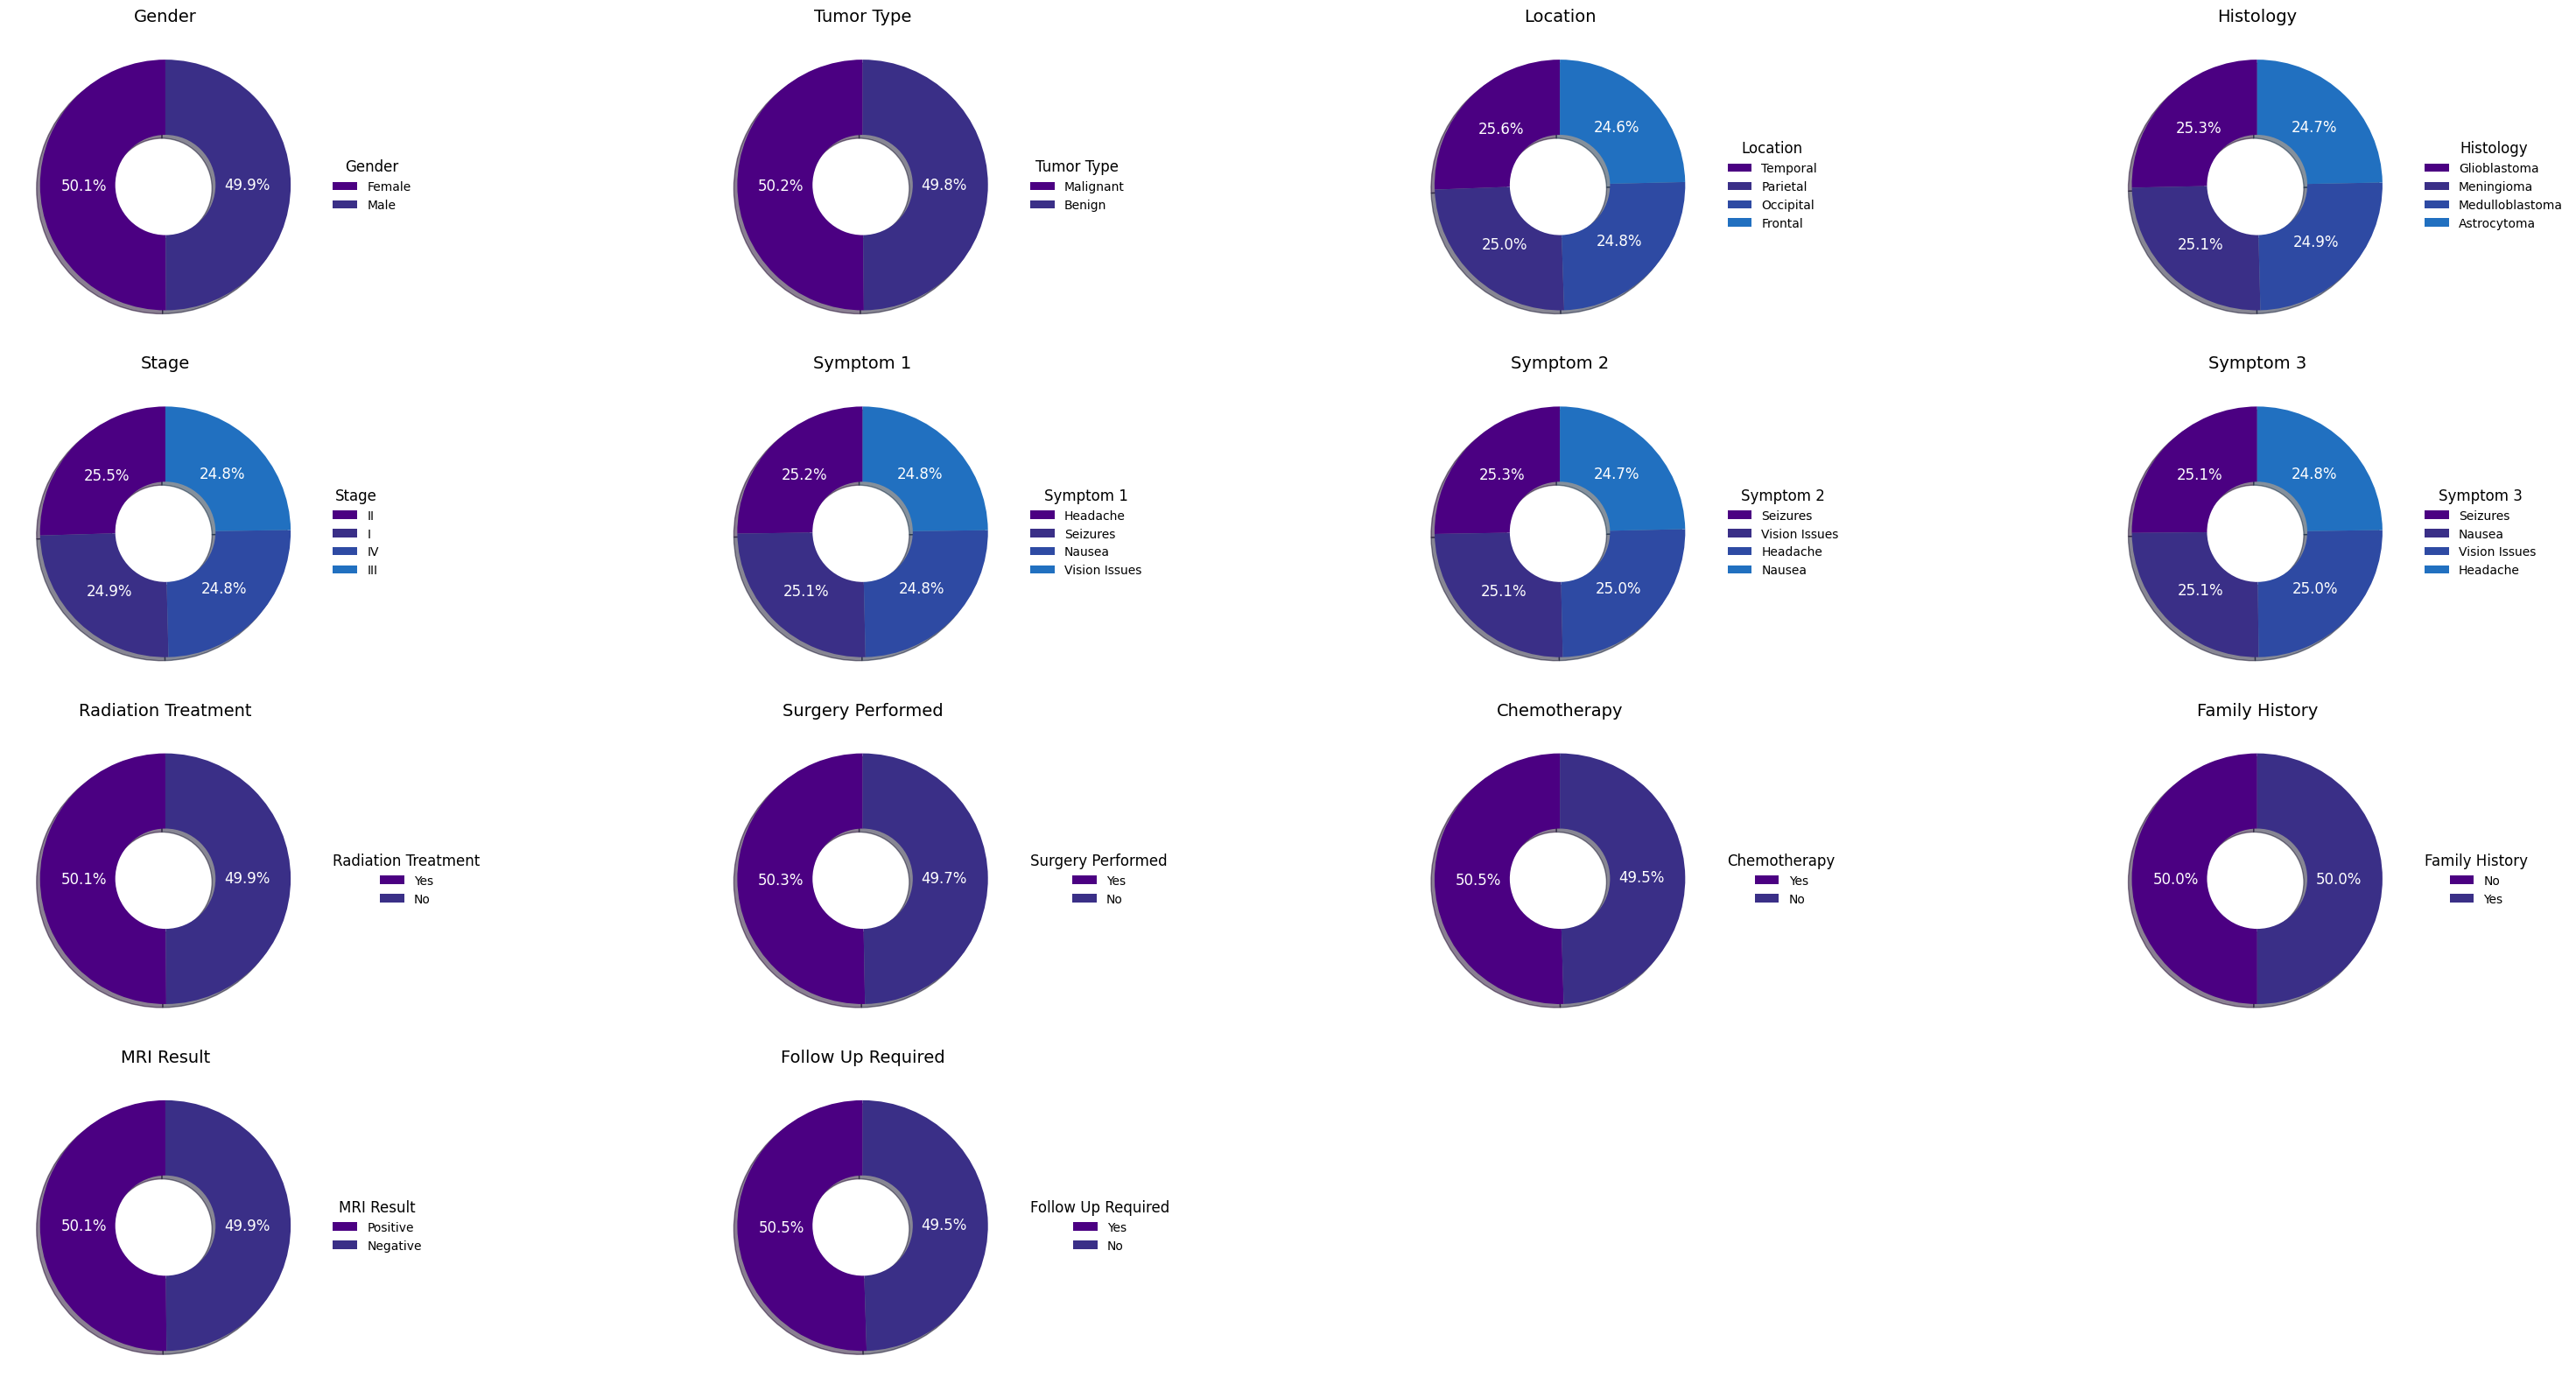

In [77]:
n_cols = 4
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig,axes = plt.subplots(n_rows, n_cols, figsize=(n_rows * 8, n_cols * 4))
axes = axes.flatten()

plot_idx = 0

valid_cols = [col for col in cat_cols if len(df[col].unique()) < 10]

for col in valid_cols:
    data = df[col].value_counts()

    wedges, text, autotexts = axes[plot_idx].pie(
        x = data,
        autopct = lambda p: f'{p:.1f}%' if p >= 10 else "",
        startangle = 90,
        colors = color,
        # explode = (0.035,0.1,0.035,0.035,0.1),
        pctdistance = 0.65,
        wedgeprops = dict(width=0.6),
        shadow = True
    )

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(12)

        axes[plot_idx].legend(
        wedges,
        [label for label in data.index],
        title=col.replace("_", " "),
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        frameon=False,
        title_fontsize=12,
        fontsize=10
    )

    axes[plot_idx].set_title(col.replace("_", " "), fontsize=14)
    plot_idx += 1

for j in range(plot_idx, n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
    

__Hasil Analisis__ <br>
data kategorikal disini terlihat sangat baik semua data terlihat balanced tidak ada data yang imbalanced

#### Cek Outlier Data

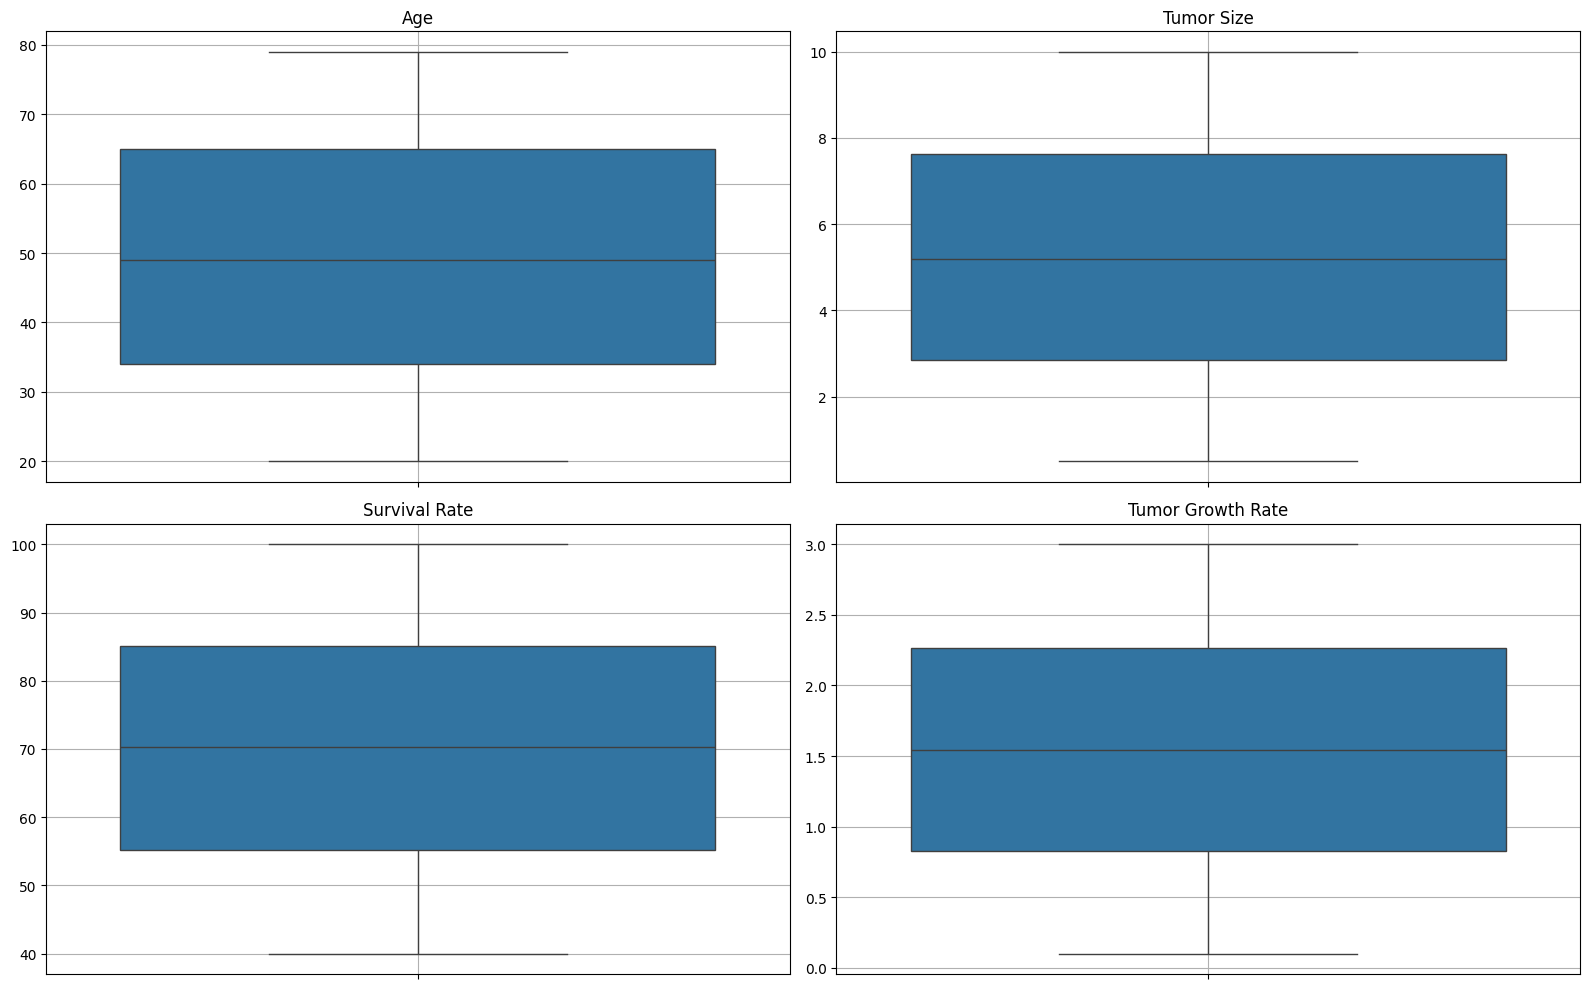

In [78]:
n_cols = 2
n_rows = int(np.ceil(len(num_col) / n_cols))

fig,axes = plt.subplots(n_rows, n_cols, figsize=(n_rows * 8,n_cols * 5))
axes = axes.flatten()

for i, col in enumerate(num_col):
    data = df[col]

    axes[i].set_title(col.replace("_", " "))
    sns.boxplot(y=data, ax=axes[i])
    axes[i].set_ylabel(None)
    axes[i].grid(True)

for j in range(len(num_col), n_rows * n_cols):
    plt.delaxes(axes[j])

plt.tight_layout()
plt.show()

__Hasil Analisis__ <br>
kolom numerik juga datanya sudah sangat baik tidak ada data yang outlier

# 4. Feature Selection

In [79]:
def LableEncoder(df: pd.DataFrame):
    unq_map = dict()
    for col in cat_cols:
        unq = df[col].unique()
        unq_map[col] = {v: k for k, v in enumerate(unq)}
        df[col] = df[col].map(unq_map[col])

    return df, unq_map

In [80]:
df_enc, struct = LableEncoder(df)
df.head().style.set_properties(**df_style).set_table_styles(table_style)

,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,73,0,0,5.375612,0,0,0,0,0,0,0,0,0,51.312579,0.111876,0,0,0
1,26,0,1,4.847098,1,1,1,1,1,1,1,1,1,46.373273,2.165736,1,0,0
2,31,0,1,5.588391,1,2,2,0,1,0,0,0,0,47.072221,1.884228,0,1,1
3,29,0,0,1.436600,0,3,3,0,0,2,1,0,1,51.853634,1.283342,1,1,1
4,54,1,1,2.417506,1,1,2,1,1,0,0,0,1,54.708987,2.069477,0,0,0


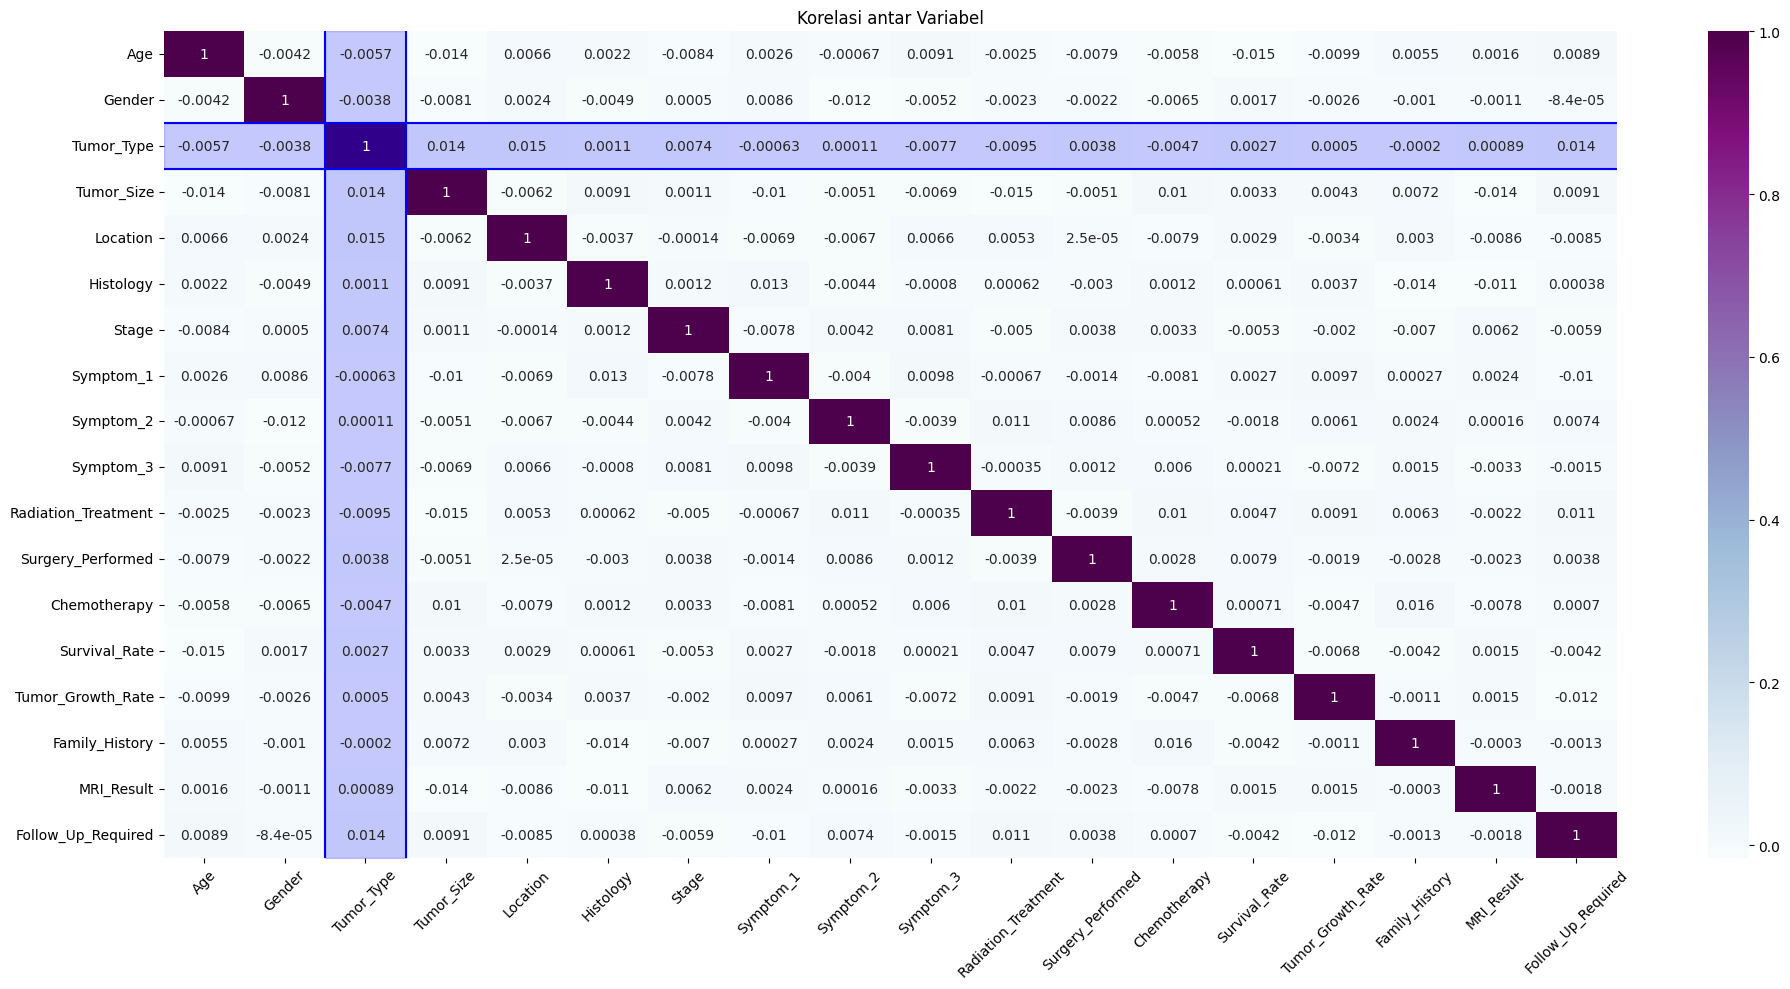

In [81]:
corr = df_enc.corr()
idx = list(corr.columns).index("Tumor_Type")
plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, cmap='BuPu')

plt.axvline(idx, color='blue', linewidth=1.5)
plt.axvline(idx + 1, color='blue', linewidth=1.5)
plt.fill_betweenx(y=[0, corr.shape[0]], x1=idx, x2=idx + 1, color='blue', alpha=0.2)

plt.axhline(idx, color='blue', linewidth=1.5)
plt.axhline(idx + 1, color='blue', linewidth=1.5)
plt.fill_between(x=[0, df.shape[0]], y1=idx, y2=idx + 1, color='blue', alpha=0.2)  

plt.title("Korelasi antar Variabel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [82]:
def mutual_information(x, y, bins=10):
    x = np.digitize(x, bins=np.histogram_bin_edges(x, bins=bins))
    y = np.digitize(y, bins=np.histogram_bin_edges(y, bins=bins))

    N = len(x)
    mi = 0

    x_values = np.unique(x)
    y_values = np.unique(y)

    for xi in x_values:
        for yi in y_values:
            p_xy = np.sum((x == xi) & (y == yi)) / N
            if p_xy == 0:
                continue
            p_x = np.sum(x == xi) / N
            p_y = np.sum(y == yi) / N
            mi += p_xy * np.log2(p_xy / (p_x * p_y))
    
    return mi

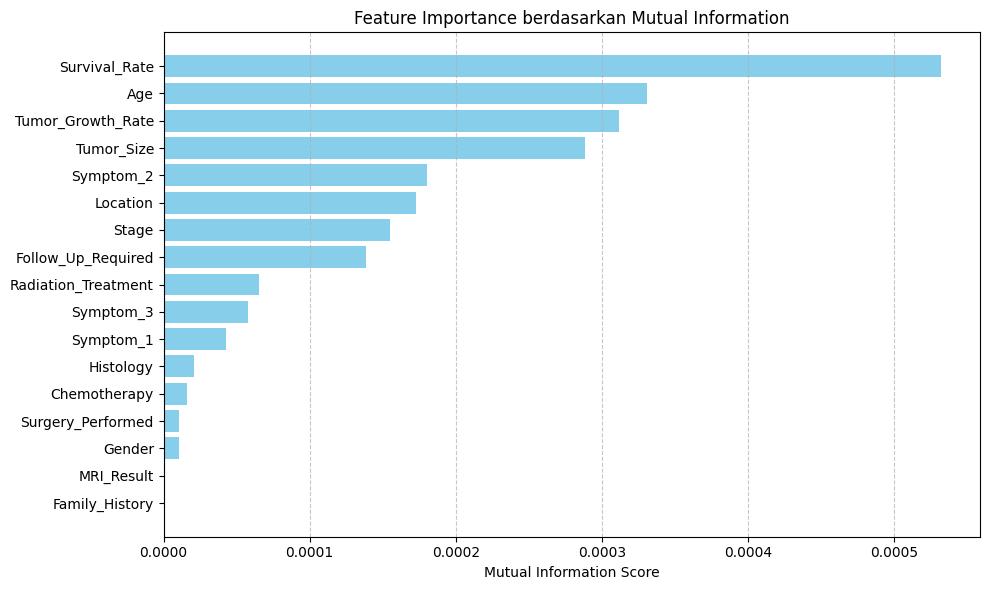

In [83]:
X = df_enc.drop(columns='Tumor_Type')
y = df_enc['Tumor_Type']

mi_scores = {col: mutual_information(X[col], y) for col in X.columns}

sorted_mi = sorted(mi_scores.items(), key=lambda x: x[1], reverse=True)
features = [k for k, _ in sorted_mi]
scores = [v for _, v in sorted_mi]

plt.figure(figsize=(10, 6))
bars = plt.barh(features[::-1], scores[::-1], color='skyblue')
plt.xlabel("Mutual Information Score")
plt.title("Feature Importance berdasarkan Mutual Information")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

__Hasil Analisis__<br>
Setelah Menganalisa korelasi dan mutual information yang saya lakukan maka saya akan memilih feature dengan treshold yang diatas __0.0001__ dan tresshold yang di bawah itu akan saya drop, namun ada beberapa feature di bawah tresshold yaitu **Symptom_3 dan Symptom_1** kenapa saya ambil 2 feature ini padahal ini nilai nya di bawah tresshold? karena feature ini masih ada kemungkinan bisa membantu model karena ini kolom untuk menampilkan gejala yang di alami ini seharusnya akan ada kaitan nya dengan __Symptom 1,2, dan 3__ meskipun saat di MI ini terlihat Symptom_2 saja yang terlihat memiliki pengaruh tapi Symptom yng lain pasti juga memiliki pengaruh terhadap prediksi nantinya 

In [84]:
df_select_fe = df_enc.drop(columns=['Radiation_Treatment', 'Histology', 'Chemotherapy', 'Surgery_Performed', 'Gender', 'MRI_Result', 'Family_History'])
df_select_fe.head().style.set_properties(**df_style).set_table_styles(table_style).apply(target_column, axis=1).applymap_index(target_header, axis=1)

C:\Users\Admin\AppData\Local\Temp\ipykernel_14236\1820216231.py:2: FutureWarning: Styler.applymap_index has been deprecated. Use Styler.map_index instead.
  df_select_fe.head().style.set_properties(**df_style).set_table_styles(table_style).apply(target_column, axis=1).applymap_index(target_header, axis=1)


,Age,Tumor_Type,Tumor_Size,Location,Stage,Symptom_1,Symptom_2,Symptom_3,Survival_Rate,Tumor_Growth_Rate,Follow_Up_Required
0,73,0,5.375612,0,0,0,0,0,51.312579,0.111876,0
1,26,1,4.847098,1,1,1,1,1,46.373273,2.165736,0
2,31,1,5.588391,1,2,0,1,0,47.072221,1.884228,1
3,29,0,1.436600,0,3,0,0,2,51.853634,1.283342,1
4,54,1,2.417506,1,2,1,1,0,54.708987,2.069477,0


### Spliting data

In [85]:
def train_test_split(X: pd.DataFrame, y: pd.DataFrame, test_size=0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)
    
    n_samples = len(X)
    shuffle_indices = np.random.permutation(np.arange(n_samples))

    test_size = round(n_samples * test_size)
    train_size = test_size - n_samples

    train_indices = shuffle_indices[:train_size]
    test_indices = shuffle_indices[test_size:]

    X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
    y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]

    return [X_train, X_test, y_train, y_test]

In [86]:
X = df.drop(columns=["Tumor_Type", 'Radiation_Treatment', 'Histology', 'Chemotherapy', 'Surgery_Performed', 'Gender', 'MRI_Result', 'Family_History'])
y = df.Tumor_Type

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

X_train.head()

,Age,Tumor_Size,Location,Stage,Symptom_1,Symptom_2,Symptom_3,Survival_Rate,Tumor_Growth_Rate,Follow_Up_Required
10650,60,4.185355,0,1,3,1,1,94.739701,0.128492,0
2041,29,6.391747,0,2,3,2,0,49.751461,1.724219,1
8668,28,1.129997,1,3,0,0,3,95.452798,1.228702,0
1114,69,2.188328,0,1,0,1,2,92.178737,1.096059,0
13902,69,5.847122,2,1,1,3,0,90.654556,2.415105,0


### Scaler<br>
1. Min Max Scaler
$$\frac{X - X_{min}}{X_{max} - X_{min}}$$

2. Standard Scaler
$$\frac{X - \bar{X}}{\sigma}$$

In [87]:
def min_max_scaler(X: pd.DataFrame):
    return (X - X.min(axis=0) / (X.max(axis=0) - X.min(axis=0)))

def std_scaler(X: pd.DataFrame):
    return (X - X.mean(axis=0) / X.std(axis=0))

In [88]:
X_train_mm_scaler = min_max_scaler(X_train)
X_test_mm_scaler = min_max_scaler(X_test)

X_train_mm_scaler.head()

,Age,Tumor_Size,Location,Stage,Symptom_1,Symptom_2,Symptom_3,Survival_Rate,Tumor_Growth_Rate,Follow_Up_Required
10650,59.661017,4.132303,0.0,1.0,3.0,1.0,1.0,94.072948,0.093033,0.0
2041,28.661017,6.338695,0.0,2.0,3.0,2.0,0.0,49.084707,1.688760,1.0
8668,27.661017,1.076944,1.0,3.0,0.0,0.0,3.0,94.786044,1.193243,0.0
1114,68.661017,2.135275,0.0,1.0,0.0,1.0,2.0,91.511983,1.060600,0.0
13902,68.661017,5.794070,2.0,1.0,1.0,3.0,0.0,89.987803,2.379645,0.0


In [89]:
X_train_std_scaler = std_scaler(X_train)
X_test_std_scaler = std_scaler(X_test)

X_train_std_scaler.head()

,Age,Tumor_Size,Location,Stage,Symptom_1,Symptom_2,Symptom_3,Survival_Rate,Tumor_Growth_Rate,Follow_Up_Required
10650,57.107867,2.269058,-1.337359,-0.332317,1.656725,-0.327769,-0.364645,90.646669,-1.737122,-0.98696
2041,26.107867,4.475450,-1.337359,0.667683,1.656725,0.672231,-1.364645,45.658428,-0.141395,0.01304
8668,25.107867,-0.786300,-0.337359,1.667683,-1.343275,-1.327769,1.635355,91.359766,-0.636912,-0.98696
1114,66.107867,0.272031,-1.337359,-0.332317,-1.343275,-0.327769,0.635355,88.085705,-0.769556,-0.98696
13902,66.107867,3.930825,0.662641,-0.332317,-0.343275,1.672231,-1.364645,86.561524,0.549490,-0.98696


### Build KNN Model<br>
1. Inisialisasi nilai K untuk area cangkupan KNN, dan P untuk tipe distance 1 untuk Manhattan 2 untuk Euclidean, $\ge$ 3 adalah Minkowski
2. Mengukur semua jarak label dengan fitur-fitur
3. Mengurutkan dan membuat cangkupan wilayah target dengan panjang K (filterisasi)
4. Mendapatkan label-label(y) berdasarkan jarak yang sudah didapat
5. Mendapatkan jarak-jarak kembali namun yang sudah di urutkan dan di filter
6. Menentukan kandidat-kandidat mana yang paling sering muncul, jika hasilnya sama akan di random choice

In [90]:
class KNN:
    def __init__(self, k:int, p:int, weight, random_state=None):
        self.k = k
        self.p = p
        self.weight = weight
        self.random_state = random_state
    
    def _minkowski_distance(self, a: pd.DataFrame, b: pd.DataFrame):
        return np.power(np.sum(np.abs(a - b) ** self.p, axis=1), 1/self.p)
    
    def _get_nn(self, X_test: pd.DataFrame):
        if self.random_state:
            np.random.seed(self.random_state)

        distance = self._minkowski_distance(X_test, self.X_train)
        k_idxs = np.argsort(distance)[:self.k]
        k_labels = [self.y_train[i] for i in k_idxs]
        k_distance = [distance[i] for i in k_idxs]

        if self.weight == "uniform":
            values, counts = np.unique(k_labels, return_counts=True)
            max_count = np.max(counts)
            candidates = values[counts == max_count]
            return np.random.choice(candidates)
        
        elif self.weight == "distance":
            weights = [1 / (d + 1e-5) for d in k_distance]

        elif callable(self.weight):
            weights = [self.weight(d) for d in k_distance]
        
        label_weight = dict()
        for label, weight in zip(k_labels, weights):
            label_weight[label] = label_weight.get(label, 0) + weight
        
        max_weight = max(label_weight.values())
        candidates = [
            label 
            for label, weight in label_weight.items() 
            if weight == max_weight
        ]
        return np.random.choice(candidates)

    def fit(self, X_train: pd.DataFrame, y_train: pd.DataFrame):
        self.X_train = X_train.to_numpy()
        self.y_train = y_train.to_numpy()

    def predict(self, X_test: pd.DataFrame):
        return np.array([
            self._get_nn(x)
            for x in X_test.to_numpy()
        ])

### Evaluation Model<br>
1. Accuracy 
$$\frac{y - \hat{y}}{total}$$
2. Precision 
$$\frac{TP}{TP - TN}$$
3. Recall 
$$\frac{TP}{TP - FN}$$
4. F1-Score 
$$2 \cdot \frac{PR}{P + R}$$
5. Macro Avg
$$\frac{P + R + F1}{3}$$
6. Weighted Avg
$$T\left(\sum \frac{M  \times weight}{total\_weight}\right)$$

In [91]:
class EvaluationModel:
    def __init__(self, y_true: pd.DataFrame, y_pred: np.ndarray):
        self.y_true = y_true.to_numpy()
        self.y_pred = y_pred
    
    def accuracy(self):
        return np.sum(self.y_true == self.y_pred) / len(self.y_true)
    
    def precision(self, TP, FP):
        return TP / (TP + FP) if (TP + FP) != 0 else 0
    
    def recall(self, TP, FN):
        return TP / (TP + FN) if (TP + FN) != 0 else 0
    
    def f1_score(self, TP, FP, FN):
        P = self.precision(TP, FP)
        R = self.recall(TP, FN)

        return 2 * (P * R) / (P + R) if (P + R) != 0 else 0
    
    def macro_avg(self, report_df: pd.DataFrame):
        return report_df[["Precision", "Recall", "F1-Score"]].mean()
    
    def weighted_avg(self, report_df: pd.DataFrame):
        weights = np.bincount(self.y_true)
        total = weights.sum()

        return (report_df[["Precision", "Recall", "F1-Score"]].T * weights / total).T.sum()

    def make_report(self):
        cats = pd.Series(self.y_true).unique()

        reports = {"Category": [], "Precision": [], "Recall": [], "F1-Score": []}

        for cat in cats:
            # Confusion Matrixs
            TP = np.sum((self.y_true == cat) & (self.y_pred == cat)) # Asli positif prediksi positif
            TN = np.sum((self.y_true != cat) & (self.y_pred != cat)) # Asli negatif prediksi negatif
            FP = np.sum((self.y_true != cat) & (self.y_pred == cat)) # Asli negatif prediksi positif
            FN = np.sum((self.y_true == cat) & (self.y_pred != cat)) # Asli positif prediksi negatif

            # Calculation Matrixs
            P = self.precision(TP, FP)
            R = self.recall(TP, FN)
            F1 = self.f1_score(TP, FP, FN)

            # Append Matrixs
            reports["Category"].append(cat)
            reports["Precision"].append(P)
            reports["Recall"].append(R)
            reports["F1-Score"].append(F1)

        accuracy = self.accuracy()
        result_df = pd.DataFrame(reports)
        macro_avg = self.macro_avg(result_df)
        weighted_avg = self.macro_avg(result_df)

        summary_record = pd.DataFrame.from_records([
            {"Category": 'macro avg', **macro_avg},
            {"Category": 'weighted avg', **weighted_avg},
        ])

        result_df = pd.concat([result_df, summary_record], ignore_index=True)

        return result_df, accuracy

### Grid Search / Tunning parameter

In [92]:
def log_model_process(params, index, total):
    progress_bar = f"[{index}/{total}] [{index/total*100:.1f}%]"
    separator = "=" * 100
    
    print(f"{separator}")
    print(f"{progress_bar} Evaluating model with params:")
    print(params)
    print(f"{separator}\n")

def search_best_model(params: dict, limit_data=None):
    total = (
        len(params["K"]) *
        len(params["P"]) *
        len(params["weights"]) *
        len(params["random_states"]) *
        len(params["scaler"])
    )

    count = 1

    models = list()

    for k in params["K"]:
        for p in params["P"]:
            for weight in params["weights"]:
                for rs in params["random_states"]:
                    for i, (train, test) in enumerate(params["scaler"]):
                        # Initialization model
                        model = KNN(k=k, p=p, weight=weight, random_state=rs)
                        model.fit(X_train=train[:limit_data], y_train=y_train[:limit_data])
                        
                        preds = model.predict(X_test=test[:limit_data])

                        # Evalutaion
                        eval_model = EvaluationModel(y_pred=preds, y_true=y_test[:limit_data])
                        result_df, accuracy = eval_model.make_report()

                        params_result = {
                            "K": k,
                            "P": p,
                            "weights": weight,
                            "random_states": rs,
                            "scaler": i
                        }

                        log_model_process(params_result, count, total)

                        models.append({
                            "params": params_result,
                            "accuracy": accuracy,
                            "result_df": result_df
                        })

                        count += 1
    return models

In [93]:
def custom_distance(d):
    return 1 / (d ** 2 + 1e-5)

params = {
    "K": range(3, 9),
    "P": range(1, 3),
    "weights": ["uniform", "distance", custom_distance],
    "random_states": [0, 42, 99],
    "scaler": [(X_train_mm_scaler, X_test_mm_scaler), (X_train_std_scaler, X_test_std_scaler), (X_train, X_test)]
}

models = search_best_model(params, limit_data=1500)

[1/324] [0.3%] Evaluating model with params:
{'K': 3, 'P': 1, 'weights': 'uniform', 'random_states': 0, 'scaler': 0}

[2/324] [0.6%] Evaluating model with params:
{'K': 3, 'P': 1, 'weights': 'uniform', 'random_states': 0, 'scaler': 1}

[3/324] [0.9%] Evaluating model with params:
{'K': 3, 'P': 1, 'weights': 'uniform', 'random_states': 0, 'scaler': 2}

[4/324] [1.2%] Evaluating model with params:
{'K': 3, 'P': 1, 'weights': 'uniform', 'random_states': 42, 'scaler': 0}

[5/324] [1.5%] Evaluating model with params:
{'K': 3, 'P': 1, 'weights': 'uniform', 'random_states': 42, 'scaler': 1}

[6/324] [1.9%] Evaluating model with params:
{'K': 3, 'P': 1, 'weights': 'uniform', 'random_states': 42, 'scaler': 2}

[7/324] [2.2%] Evaluating model with params:
{'K': 3, 'P': 1, 'weights': 'uniform', 'random_states': 99, 'scaler': 0}

[8/324] [2.5%] Evaluating model with params:
{'K': 3, 'P': 1, 'weights': 'uniform', 'random_states': 99, 'scaler': 1}

[9/324] [2.8%] Evaluating model with params:
{'K': 

### Results

In [94]:
sorted_models = sorted(models, key=lambda x: x["accuracy"], reverse=True)[:3]

for model in sorted_models:
    print(f"Params: {model["params"]}")
    display(model["result_df"])
    print(f"Accuracy: {model["accuracy"]}\n\n")

Params: {'K': 6, 'P': 1, 'weights': 'uniform', 'random_states': 0, 'scaler': 1}


,Category,Precision,Recall,F1-Score
0,1,0.504775,0.518934,0.511757
1,0,0.552803,0.538755,0.545689
2,macro avg,0.528789,0.528844,0.528723
3,weighted avg,0.528789,0.528844,0.528723


Accuracy: 0.5293333333333333


Params: {'K': 4, 'P': 2, 'weights': 'uniform', 'random_states': 42, 'scaler': 1}


,Category,Precision,Recall,F1-Score
0,1,0.504405,0.321178,0.392459
1,0,0.537285,0.714104,0.613202
2,macro avg,0.520845,0.517641,0.502831
3,weighted avg,0.520845,0.517641,0.502831


Accuracy: 0.5273333333333333


Params: {'K': 8, 'P': 1, 'weights': <function custom_distance at 0x00000276E079BE20>, 'random_states': 0, 'scaler': 1}


,Category,Precision,Recall,F1-Score
0,1,0.50000,0.507714,0.503827
1,0,0.54768,0.540025,0.543826
2,macro avg,0.52384,0.523870,0.523827
3,weighted avg,0.52384,0.523870,0.523827


Accuracy: 0.5246666666666666




Dari top 3 model di atas kita mendapatkan parameter terbaik yakni:
- K: 6
- P: 1
- weight: uniform
- random_state: 0
- scaler: index ke-1

### Implements with good params

In [101]:
final_model = KNN(k=6, p=1, weight="uniform", random_state=0)
final_model.fit(X_train=X_train_std_scaler, y_train=y_train)

preds = final_model.predict(X_test=X_test_std_scaler)

In [102]:
final_eval_model = EvaluationModel(y_pred=preds, y_true=y_test)
result_df, accuracy = final_eval_model.make_report()

display(result_df)
print(f"Accuracy: {accuracy}")

,Category,Precision,Recall,F1-Score
0,1,0.499187,0.500815,0.500000
1,0,0.502562,0.500934,0.501747
2,macro avg,0.500875,0.500875,0.500873
3,weighted avg,0.500875,0.500875,0.500873


Accuracy: 0.500875


Hasilnya mungkin lebih turun karena pada saat grid search hanya menggunakan 100 sampel, sedangkan saat implements menggunakan semua sampel.